In [1]:
import multiprocessing
multiprocessing.cpu_count()

12

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import pandas as pd
from lmfit import minimize, Parameters
import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)
from magE.directMethod import directT, run_all

In [3]:
# Read data
dataPath = '/home/benjamin/Documents/analogs/specs/'
spec = pd.read_csv(dataPath + 'j0021+0052.csv', dtype=np.float64)
wl, flux, noise = spec.T.to_numpy()
flux = flux * 1e14
noise = noise* 1e14

In [4]:
def gaussian(x, A, mu, z, sigma):
    amplitude = A / np.sqrt(2 * np.pi) / sigma
    exp = np.exp(-(x - mu * (1 + z))**2 / 2 / sigma**2 )
    return amplitude * exp

In [5]:
ha_mask = (wl > 6530) & (wl < 6605)
wl_ha = wl[ha_mask]
flux_ha = flux[ha_mask]
noise_ha = noise[ha_mask]

In [7]:
o3_mask = (wl > 4825) & (wl < 5050)
wl_o3 = wl[o3_mask]
flux_o3 = flux[o3_mask]
noise_o3 = noise[o3_mask]

<ErrorbarContainer object of 3 artists>

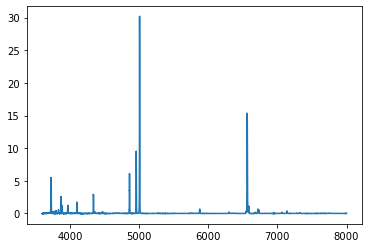

In [9]:
%matplotlib inline
plt.errorbar(wl, flux, noise)

# H$\beta$ + [OIII]4959 + [OIII]5007

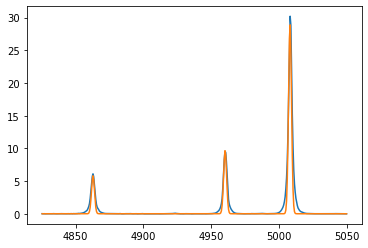

In [29]:
# Search for good initial guess

plt.plot(wl_o3, flux_o3)

oiiia_wav = 5008.239
oiiib_wav = 4960.295
hb_wav = 4862.721

hb = gaussian(wl_o3, 80 * 1/5, hb_wav, z=0.0, sigma=1.1)
oiiib = gaussian(wl_o3, 80 * 1/3, oiiib_wav, z=0.0, sigma=1.1)
oiiia = gaussian(wl_o3, 80, oiiia_wav, z=0.0, sigma=1.1)

plt.plot(wl_o3, hb + oiiib + oiiia)

In [32]:
params_oiii_hb = Parameters()
params_oiii_hb.add('z', value=2.8e-04)
params_oiii_hb.add('sigma', value=1.1, min=0.)
params_oiii_hb.add('Oiiia_flux', value=80, min=0.)
params_oiii_hb.add('Oiiib_to_Oiiia', value=1/3, min=0., max=1.)
params_oiii_hb.add('Hb_to_Oiiia', value=1/5, min=0., max=1.)

def residual_oiii_hb(params_oiii_hb, x, data, uncertainty):
    
    z = params_oiii_hb['z']
    sigma = params_oiii_hb['sigma']
    oiiia_flux = params_oiii_hb['Oiiia_flux']
    oiiib_flux = oiiia_flux * params_oiii_hb['Oiiib_to_Oiiia']
    hb_flux = oiiia_flux * params_oiii_hb['Hb_to_Oiiia']
    
    x = wl_o3
    model_oiii_hb = gaussian(x, oiiia_flux, oiiia_wav, z, sigma) \
                  + gaussian(x, oiiib_flux, oiiib_wav, z, sigma) \
                  + gaussian(x, hb_flux, hb_wav, z, sigma)
    
    return (model_oiii_hb - flux_o3) / noise_o3

In [33]:
out_oiii_hb = minimize(residual_oiii_hb, params_oiii_hb, args=(1, 1, 1),
                      method='emcee', burn=1000, steps=2500, thin=10,
                      workers=12, nwalkers=75)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 2500/2500 [00:22<00:00, 109.91it/s]

The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 74.14769596 119.17703457 128.43079995  31.0970735   79.98689009]


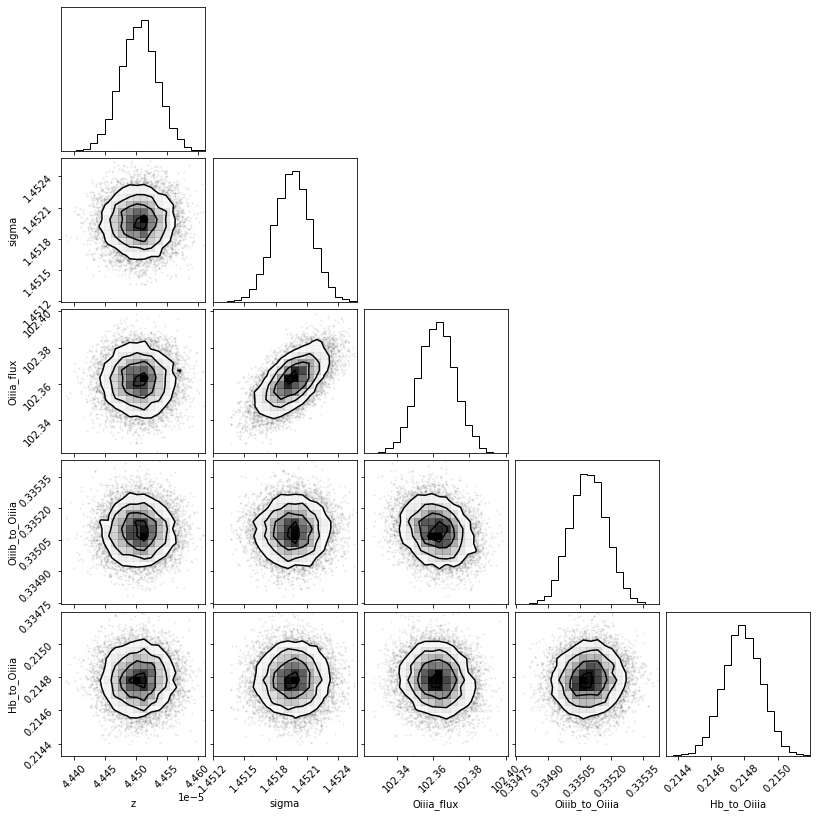

In [36]:
corner.corner(out_oiii_hb.flatchain, labels=out_oiii_hb.var_names);

In [37]:
out_oiii_hb

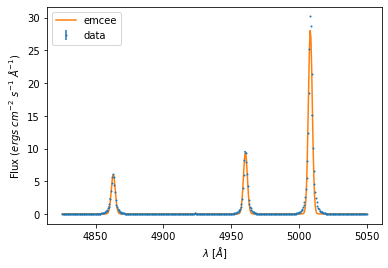

In [42]:
oiiia_flux = out_oiii_hb.flatchain.Oiiia_flux.mean()
oiiia_std = out_oiii_hb.flatchain.Oiiia_flux.std()

oiiib_flux = (oiiia_flux * out_oiii_hb.flatchain.Oiiib_to_Oiiia).mean()
oiiib_std = (oiiia_flux * out_oiii_hb.flatchain.Oiiib_to_Oiiia).std()

hb_flux = (oiiia_flux * out_oiii_hb.flatchain.Hb_to_Oiiia).mean()
hb_std = (oiiia_flux * out_oiii_hb.flatchain.Hb_to_Oiiia).std()

#bkg_oiii_hb = out_oiii_hb.flatchain.bkg.mean()
z_oiii_hb = out_oiii_hb.flatchain.z.mean()
sigma_oiii_hb = out_oiii_hb.flatchain.sigma.mean()

# Search for good initial guess

plt.errorbar(wl_o3, flux_o3, noise_o3, ls='', marker='.', markersize=2, label='data')

oiiia = gaussian(wl_o3, oiiia_flux, oiiia_wav, z_oiii_hb, sigma_oiii_hb)
oiiib = gaussian(wl_o3, oiiib_flux, oiiib_wav, z_oiii_hb, sigma_oiii_hb)
hb = gaussian(wl_o3, hb_flux, hb_wav, z_oiii_hb, sigma_oiii_hb)

plt.plot(wl_o3, hb + oiiib + oiiia, label='emcee')
plt.ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)')
plt.xlabel(r'$\lambda$ [$\AA$]')
plt.legend()

In [43]:
oiiia_flux / hb_flux

4.655765551161619

# 2 gaussians, all free

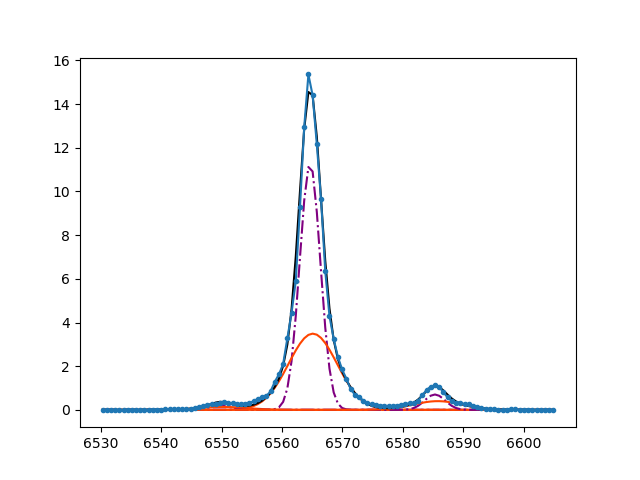

In [7]:
# Search for good initial guess
%matplotlib widget
plt.errorbar(wl_ha, flux_ha, noise_ha,
             marker='o', markersize=3, label='data')

# air
ha_wav = 6562.801
niib_wav = 6548.05
niia_wav = 6583.45

# narrow and broad

ha_nar = gaussian(wl_ha, 48, ha_wav, z=2.8e-04, sigma=1.7)
ha_brd = gaussian(wl_ha, 35, ha_wav, z=3.5e-04, sigma=4.0)

niib_nar = gaussian(wl_ha, 3/3, niib_wav, z=2.8e-04, sigma=1.7)
niib_brd = gaussian(wl_ha, 4/3, niib_wav, z=3.5e-04, sigma=4.0)

niia_nar = gaussian(wl_ha, 3, niia_wav, z=2.8e-04, sigma=1.7)
niia_brd = gaussian(wl_ha, 4, niia_wav, z=3.5e-04, sigma=4.0)

# total
ha = ha_nar + ha_brd
niib = niib_nar + niib_brd
niia = niia_nar + niia_brd

plt.plot(wl_ha, ha_nar, color='purple', ls='-.')
plt.plot(wl_ha, ha_brd, color='orangered')

plt.plot(wl_ha, niib_nar, color='purple', ls='-.')
plt.plot(wl_ha, niib_brd, color='orangered')

plt.plot(wl_ha, niia_nar, color='purple', ls='-.')
plt.plot(wl_ha, niia_brd, color='orangered')

plt.plot(wl_ha, niib + ha + niia, color='black')
#plt.plot(wl_ha, ha + niia, color='black')

In [8]:
params2_ha_nii = Parameters()

params2_ha_nii.add('z_nar', value=2.8e-04)
params2_ha_nii.add('z_brd', value=3.5e-04)
params2_ha_nii.add('sigma_nar', value=1.4, min=0.)
params2_ha_nii.add('sigma_brd', value=3.8, min=0.)
params2_ha_nii.add('Ha_nar', value=38, min=0.)
params2_ha_nii.add('Ha_brd', value=42, min=0.)
params2_ha_nii.add('Niia_nar_to_ha', value=3/48, min=0.)
params2_ha_nii.add('Niia_brd_to_ha', value=4/35, min=0.)
params2_ha_nii.add('Niib_nar_to_niia', value=1/3, vary=False)
params2_ha_nii.add('Niib_brd_to_niia', value=1/3, vary=False)


def residual2_ha_nii(params2_ha_nii, x, data, uncertainty):
    ha_wav = 6562.801
    niib_wav = 6548.05
    niia_wav = 6583.45
    
    z_nar = params2_ha_nii['z_nar']
    z_brd = params2_ha_nii['z_brd']
    sigma_nar = params2_ha_nii['sigma_nar']
    sigma_brd = params2_ha_nii['sigma_brd']
    ha_nar = params2_ha_nii['Ha_nar']
    ha_brd = params2_ha_nii['Ha_brd']
    niia_nar = params2_ha_nii['Niia_nar_to_ha']*params2_ha_nii['Ha_nar']
    niia_brd = params2_ha_nii['Niia_brd_to_ha']*params2_ha_nii['Ha_brd']
    niib_nar = params2_ha_nii['Niib_nar_to_niia']*params2_ha_nii['Niia_nar_to_ha']*params2_ha_nii['Ha_nar']
    niib_brd = params2_ha_nii['Niib_brd_to_niia']*params2_ha_nii['Niia_brd_to_ha']*params2_ha_nii['Ha_brd']
    
    x = wl_ha
    
    model_ha = gaussian(x, ha_nar, ha_wav, z_nar, sigma_nar) + gaussian(x, ha_brd, ha_wav, z_brd, sigma_brd)
    model_niia = gaussian(x, niia_nar, niia_wav, z_nar, sigma_nar) + gaussian(x, niia_brd, niia_wav, z_brd, sigma_brd)
    model_niib = gaussian(x, niib_nar, niib_wav, z_nar, sigma_nar) + gaussian(x, niib_brd, niib_wav, z_brd, sigma_brd)
    model = model_niib + model_ha + model_niia
    return (model - flux_ha) / noise_ha

In [9]:
out2_ha_nii = minimize(residual2_ha_nii, params2_ha_nii, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=3000, thin=10,
                      workers=12, nwalkers=36, seed=1)

100%|██████████████████████████████████████| 3000/3000 [00:17<00:00, 171.87it/s]

The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 60;
tau: [216.0420257  232.27101019  33.04010645  30.67050085  36.71317777
  69.81207773 334.12699722 365.30184886]


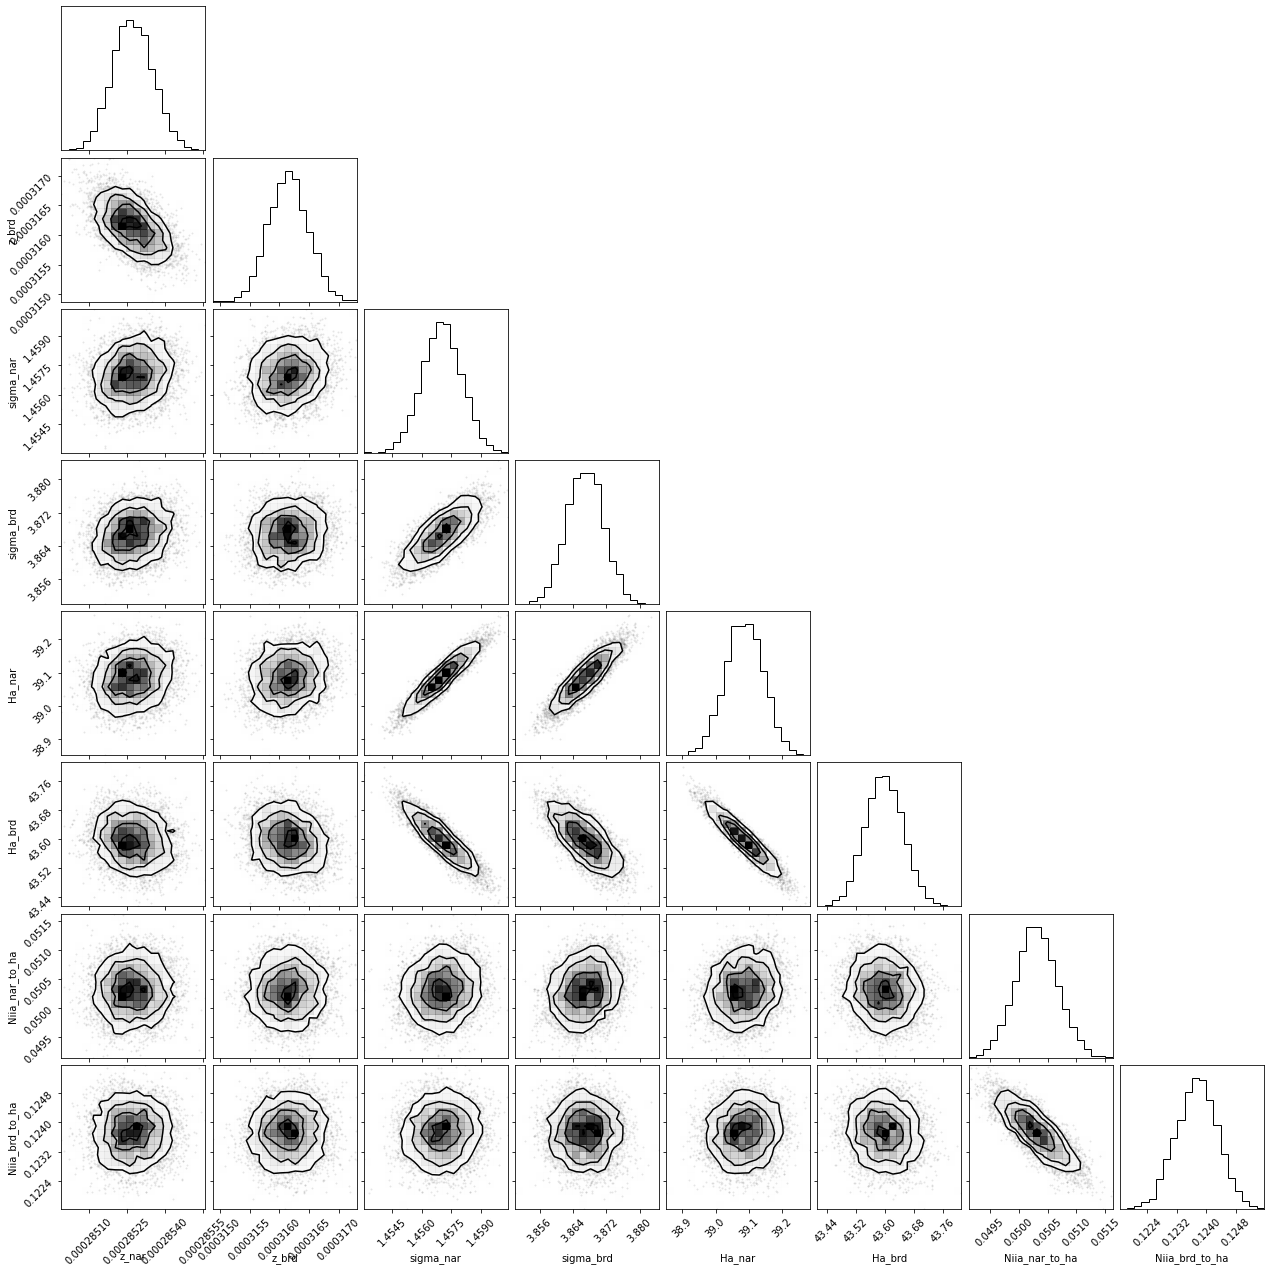

In [10]:
%matplotlib inline
corner.corner(out2_ha_nii.flatchain, labels=out2_ha_nii.var_names);

In [11]:
out2_ha_nii

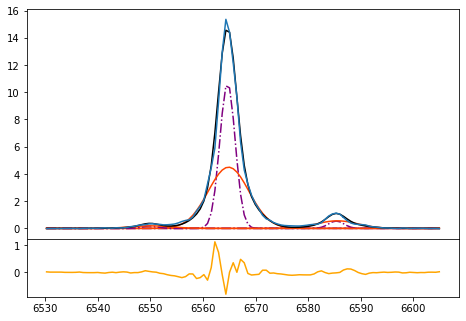

In [12]:
ha2_nar = out2_ha_nii.flatchain.Ha_nar.mean()
ha2_brd = out2_ha_nii.flatchain.Ha_brd.mean()

niia2_nar = (out2_ha_nii.flatchain.Niia_nar_to_ha*out2_ha_nii.flatchain.Ha_nar).mean()
niia2_brd = (out2_ha_nii.flatchain.Niia_brd_to_ha*out2_ha_nii.flatchain.Ha_brd).mean()

niib2_nar = ((out2_ha_nii.flatchain.Niia_nar_to_ha*out2_ha_nii.flatchain.Ha_nar)/3).mean()
niib2_brd = ((out2_ha_nii.flatchain.Niia_brd_to_ha*out2_ha_nii.flatchain.Ha_brd)/3).mean()

z2_ha_nar = out2_ha_nii.flatchain.z_nar.mean()
z2_ha_brd = out2_ha_nii.flatchain.z_brd.mean()
sigma2_ha_nar = out2_ha_nii.flatchain.sigma_nar.mean()
sigma2_ha_brd = out2_ha_nii.flatchain.sigma_brd.mean()

# Search for good initial guess
%matplotlib inline
fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))
ax.errorbar(wl_ha, flux_ha, noise_ha, markersize=2, label='data')

ha_wav = 6562.801
niib_wav = 6548.05
niia_wav = 6583.45

niib2_nar = gaussian(wl_ha, niib2_nar, niib_wav, z=z2_ha_nar, sigma=sigma2_ha_nar)
niib2_brd = gaussian(wl_ha, niib2_brd, niib_wav, z=z2_ha_brd, sigma=sigma2_ha_brd)

ha2_nar = gaussian(wl_ha, ha2_nar, ha_wav, z=z2_ha_nar, sigma=sigma2_ha_nar)
ha2_brd = gaussian(wl_ha, ha2_brd, ha_wav, z=z2_ha_brd, sigma=sigma2_ha_brd)

niia2_nar = gaussian(wl_ha, niia2_nar, niia_wav, z=z2_ha_nar, sigma=sigma2_ha_nar)
niia2_brd = gaussian(wl_ha, niia2_brd, niia_wav, z=z2_ha_brd, sigma=sigma2_ha_brd)

ha2 = ha_nar + ha_brd
niia2 = niia_nar + niia_brd
niib2 = niib_nar + niib_brd

ax.plot(wl_ha, ha2_nar, color='purple', ls='-.')
ax.plot(wl_ha, ha2_brd, color='orangered')
ax.plot(wl_ha, niia2_nar, color='purple', ls='-.')
ax.plot(wl_ha, niia2_brd, color='orangered')
ax.plot(wl_ha, niib2_nar, color='purple', ls='-.')
ax.plot(wl_ha, niib2_brd, color='orangered')
ax.plot(wl_ha, niib2 + ha2 + niia2, color='black')

ax1.plot(wl_ha, niib2 + ha2 + niia2 - flux_ha, color='orange')

# 3 gaussians with good initial guess

In [13]:
mask_ha = (wl_ha > 6552) & (wl_ha < 6577)
mask_niia = (wl_ha > 6577) & (wl_ha < 6595)
mask_niib = (wl_ha > 6540) & (wl_ha < 6552)
ha_flux = np.sum(flux_ha[mask_ha])
niia_flux = np.sum(flux_ha[mask_niia]) 
niib_flux = np.sum(flux_ha[mask_niib])

In [14]:
niia_flux/ha_flux

0.08554771118503306

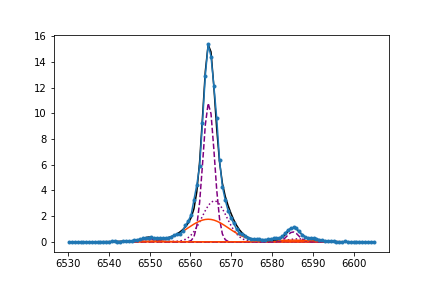

In [15]:
# Search for good initial guess
%matplotlib widget
plt.errorbar(wl_ha, flux_ha, noise_ha,
             marker='o', markersize=3, label='data')

# air
ha_wav = 6562.801
niib_wav = 6548.05
niia_wav = 6583.45

# narrow and broad

ha_nar = gaussian(wl_ha, 38, ha_wav, z=2.58e-04, sigma=1.4)
ha_mid = gaussian(wl_ha, 24, ha_wav, z=4.6966e-04, sigma=3.)
ha_brd = gaussian(wl_ha, 22, ha_wav, z=2.39e-04, sigma=5.)

niib_nar = gaussian(wl_ha, 38/42, niib_wav, z=2.58e-04, sigma=1.4)
niib_mid = gaussian(wl_ha, 24/42, niib_wav, z=4.6966e-04, sigma=5.)
niib_brd = gaussian(wl_ha, 22/42, niib_wav, z=2.39e-04, sigma=5.)

niia_nar = gaussian(wl_ha, 38/14, niia_wav, z=2.58e-04, sigma=1.4)
niia_mid = gaussian(wl_ha, 24/14, niia_wav, z=4.6966e-04, sigma=3.)
niia_brd = gaussian(wl_ha, 22/14, niia_wav, z=2.39e-04, sigma=5.)


# total
ha = ha_nar + ha_mid + ha_brd
niib = niib_nar + niib_mid + niib_brd
niia = niia_nar + niia_mid + niia_brd

plt.plot(wl_ha, ha_nar, color='purple', ls='--')
plt.plot(wl_ha, ha_mid, color='purple', ls=':')
plt.plot(wl_ha, ha_brd, color='orangered')

plt.plot(wl_ha, niib_nar, color='purple', ls='--')
plt.plot(wl_ha, niib_mid, color='purple', ls=':')
plt.plot(wl_ha, niib_brd, color='orangered')

plt.plot(wl_ha, niia_nar, color='purple', ls='--')
plt.plot(wl_ha, niia_mid, color='purple', ls=':')
plt.plot(wl_ha, niia_brd, color='orangered')

plt.plot(wl_ha, niib + ha + niia, color='black')

In [16]:
params_ha_nii = Parameters()

params_ha_nii.add('z_nar', value=2.58e-04)
params_ha_nii.add('z_mid', value=4.6966e-04)
params_ha_nii.add('z_brd', value=2.39e-04)

params_ha_nii.add('sigma_nar', value=1.4, min=0.)
params_ha_nii.add('sigma_mid', value=3., min=0.)
params_ha_nii.add('sigma_brd', value=5., min=0.)

params_ha_nii.add('Ha_nar', value=38, min=0.)
params_ha_nii.add('Ha_mid', value=24, min=0.)
params_ha_nii.add('Ha_brd', value=22, min=0.)

params_ha_nii.add('Niia_nar', value=2.71, min=0.)
params_ha_nii.add('Niia_mid', value=1.71, min=0.)
params_ha_nii.add('Niia_brd', value=1.57, min=0.)

params_ha_nii.add('Niib_to_niia', value=1/3, vary=False)

def residual_ha_nii(params_ha_nii, x, data, uncertainty):
    ha_wav = 6562.801
    niib_wav = 6548.05
    niia_wav = 6583.45
    
    z_nar = params_ha_nii['z_nar']
    z_mid = params_ha_nii['z_mid']
    z_brd = params_ha_nii['z_brd']
    
    sigma_nar = params_ha_nii['sigma_nar']
    sigma_mid = params_ha_nii['sigma_mid']
    sigma_brd = params_ha_nii['sigma_brd']
    
    ha_nar = params_ha_nii['Ha_nar']
    ha_mid = params_ha_nii['Ha_mid']
    ha_brd = params_ha_nii['Ha_brd']
    
    niia_nar = params_ha_nii['Niia_nar']
    niia_mid = params_ha_nii['Niia_mid']
    niia_brd = params_ha_nii['Niia_brd']
    
    niib_nar = params_ha_nii['Niia_nar']*params_ha_nii['Niib_to_niia']
    niib_mid = params_ha_nii['Niia_mid']*params_ha_nii['Niib_to_niia']
    niib_brd = params_ha_nii['Niia_brd']*params_ha_nii['Niib_to_niia']
    
    x = wl_ha
    
    model_ha = gaussian(x, ha_nar, ha_wav, z_nar, sigma_nar) \
             + gaussian(x, ha_brd, ha_wav, z_brd, sigma_brd) \
             + gaussian(x, ha_mid, ha_wav, z_mid, sigma_mid)
    
    model_niia = gaussian(x, niia_nar, niia_wav, z_nar, sigma_nar) \
               + gaussian(x, niia_brd, niia_wav, z_brd, sigma_brd) \
               + gaussian(x, niia_mid, niia_wav, z_mid, sigma_mid)
    
    model_niib = gaussian(x, niib_nar, niib_wav, z_nar, sigma_nar) \
               + gaussian(x, niib_brd, niib_wav, z_brd, sigma_brd) \
               + gaussian(x, niib_mid, niib_wav, z_mid, sigma_mid)
    
    model = model_niib + model_ha + model_niia
    return (model - flux_ha) / noise_ha

In [17]:
out_ha_nii3f = minimize(residual_ha_nii, params_ha_nii, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=3000, thin=10,
                      workers=12, nwalkers=36, seed=1)

100%|██████████████████████████████████████| 3000/3000 [00:22<00:00, 133.43it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 12 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 60;
tau: [407.08753184 369.62405843 411.89342044 423.88415799 416.53658649
 387.79490219 338.08700436 411.82371704 401.57468346 312.6823189
 407.95959086 388.3705792 ]


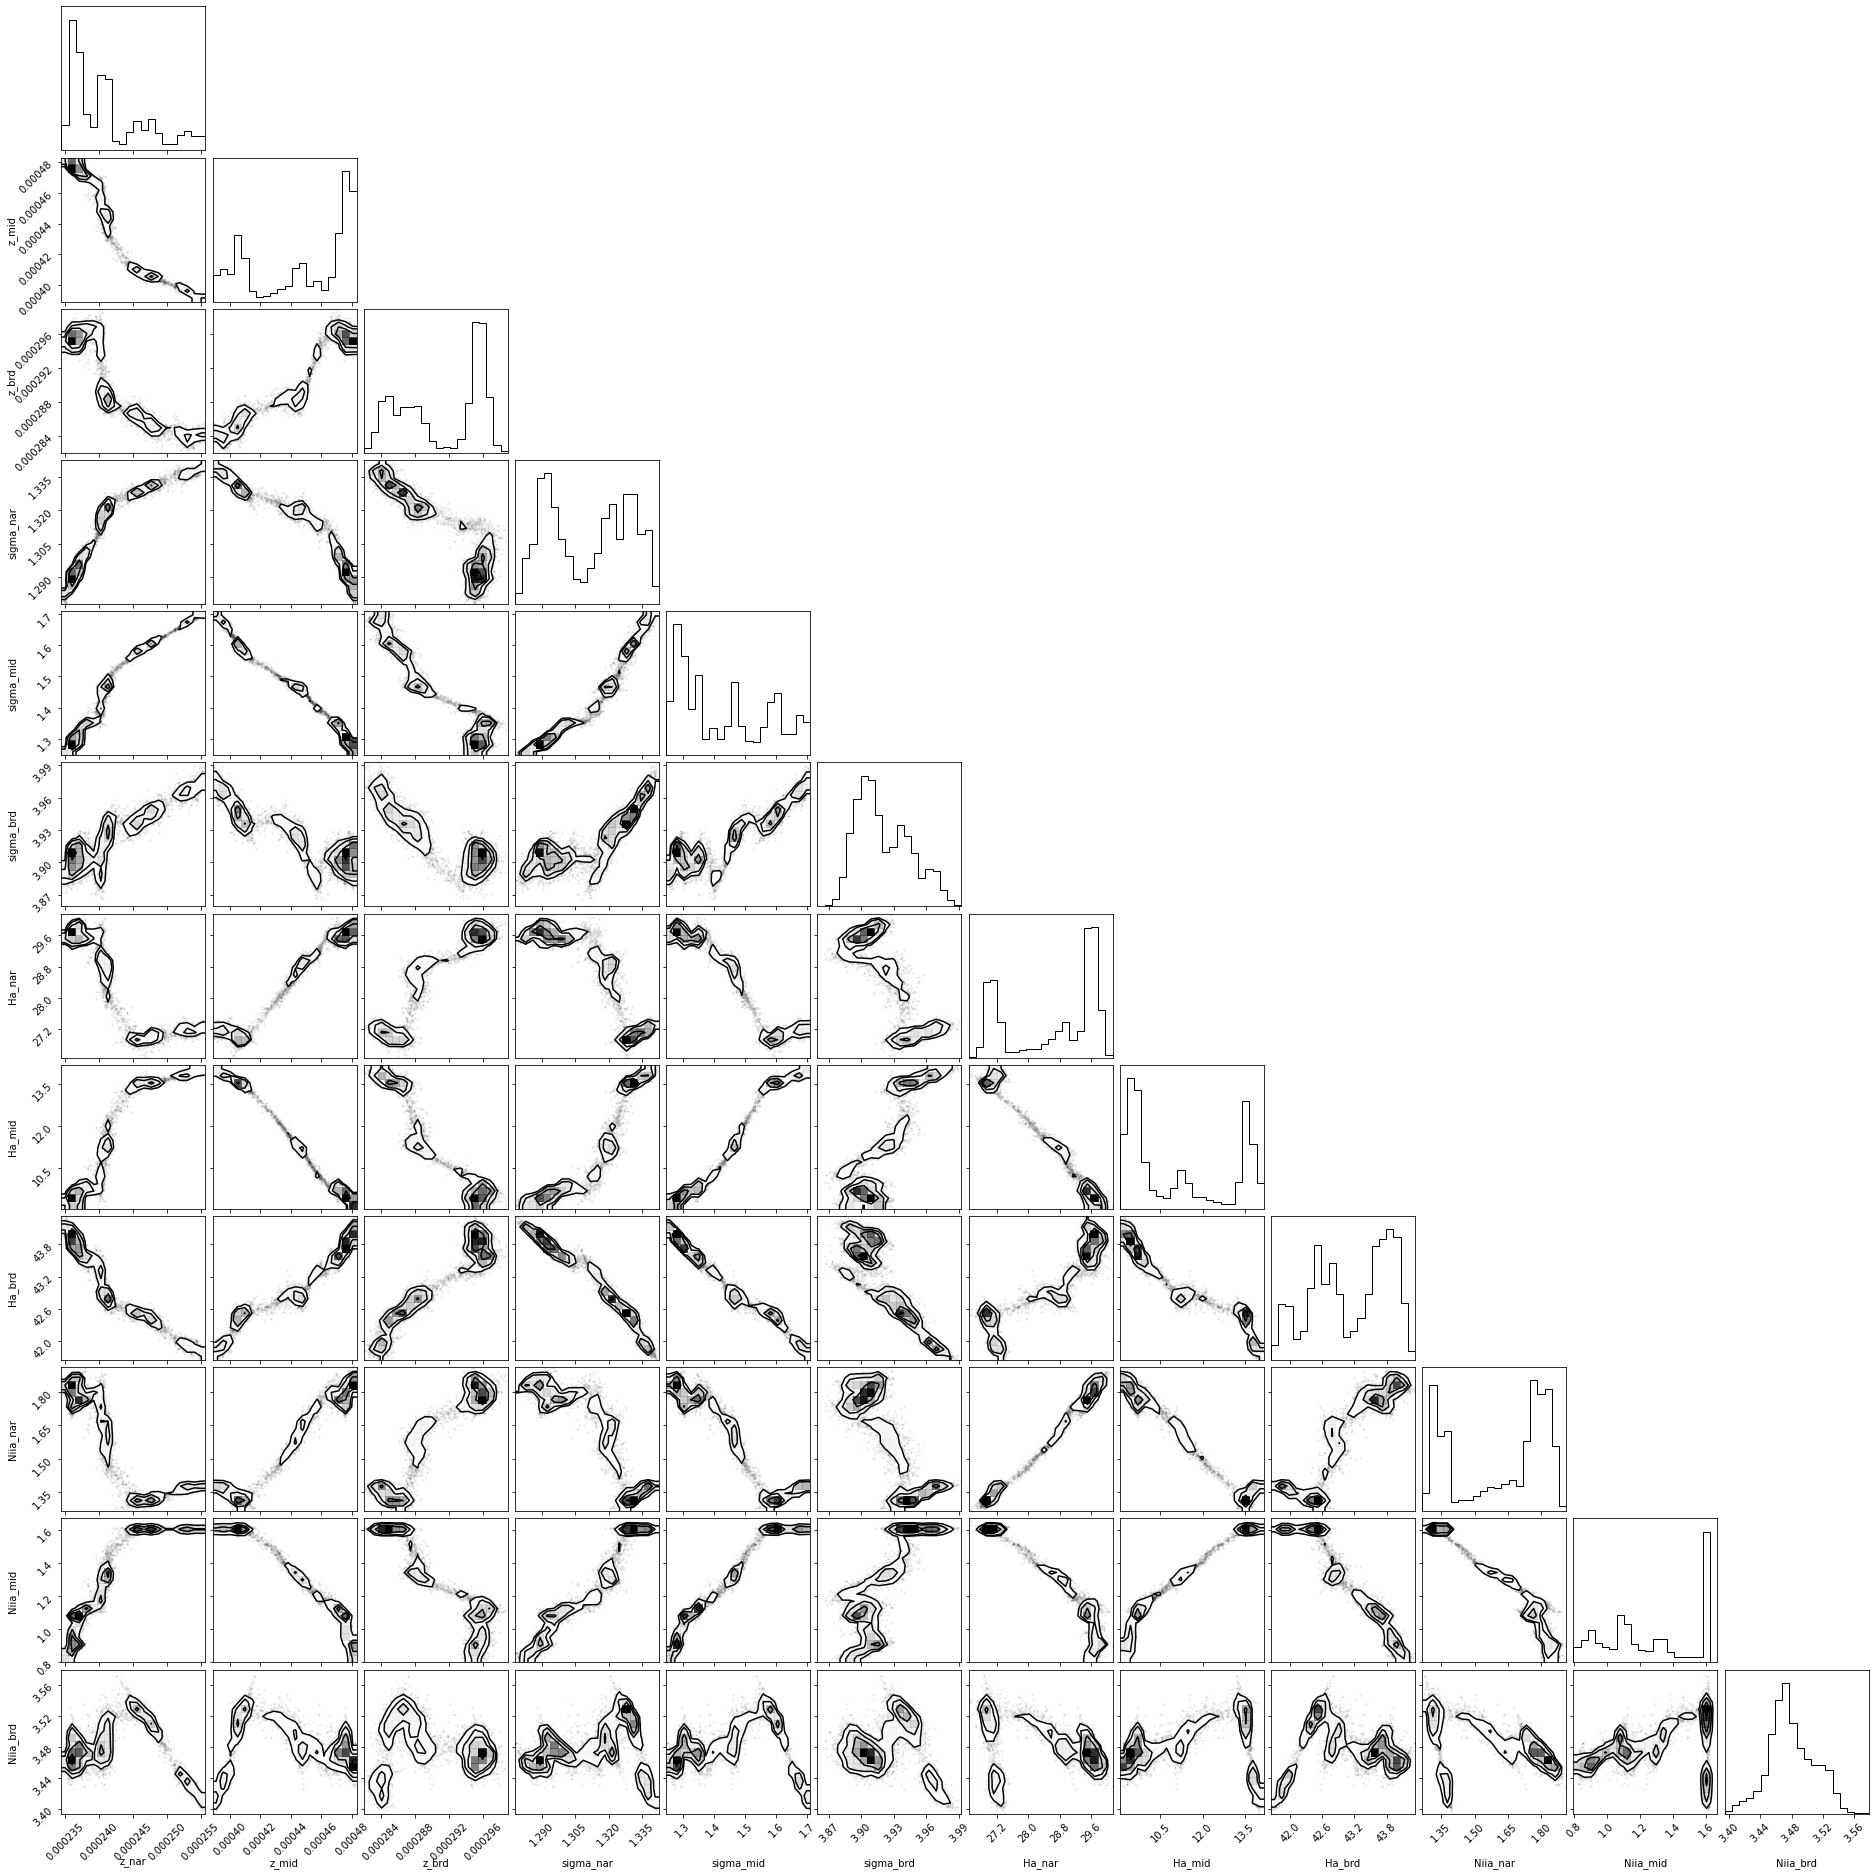

In [18]:
%matplotlib inline
corner.corner(out_ha_nii3f.flatchain, labels=out_ha_nii3f.var_names);

In [19]:
out_ha_nii3f

Using matplotlib backend: module://ipympl.backend_nbagg


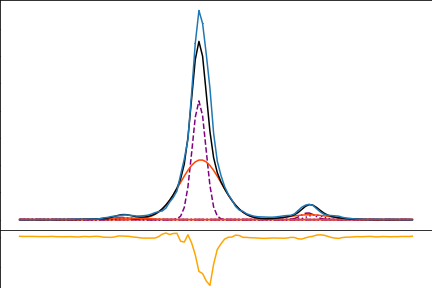

In [20]:
ha_nar = out_ha_nii3f.flatchain.Ha_nar.mean()
ha_mid = out_ha_nii3f.flatchain.Ha_mid.mean()
ha_brd = out_ha_nii3f.flatchain.Ha_brd.mean()

niia_nar = out_ha_nii3f.flatchain.Niia_nar.mean()
niia_mid = out_ha_nii3f.flatchain.Niia_mid.mean()
niia_brd = out_ha_nii3f.flatchain.Niia_brd.mean()

niib_nar = niia_nar/3
niib_mid = niia_mid/3
niib_brd = niia_brd/3

z_ha_nar = out_ha_nii3f.flatchain.z_nar.mean()
z_ha_mid = out_ha_nii3f.flatchain.z_mid.mean()
z_ha_brd = out_ha_nii3f.flatchain.z_brd.mean()

sigma_ha_nar = out_ha_nii3f.flatchain.sigma_nar.mean()
sigma_ha_mid = out_ha_nii3f.flatchain.sigma_mid.mean()
sigma_ha_brd = out_ha_nii3f.flatchain.sigma_brd.mean()


# Search for good initial guess
%matplotlib 
fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))
ax.errorbar(wl_ha, flux_ha, noise_ha, markersize=2, label='data')


ha_wav = 6562.801
niib_wav = 6548.05
niia_wav = 6583.45

niib_nar = gaussian(wl_ha, niib_nar, niib_wav, z=z_ha_nar, sigma=sigma_ha_nar)
niib_mid = gaussian(wl_ha, niib_mid, niib_wav, z=z_ha_mid, sigma=sigma_ha_mid)
niib_brd = gaussian(wl_ha, niib_brd, niib_wav, z=z_ha_brd, sigma=sigma_ha_brd)

ha_nar = gaussian(wl_ha, ha_nar, ha_wav, z=z_ha_nar, sigma=sigma_ha_nar)
ha_brd = gaussian(wl_ha, ha_brd, ha_wav, z=z_ha_brd, sigma=sigma_ha_brd)

niia_nar = gaussian(wl_ha, niia_nar, niia_wav, z=z_ha_nar, sigma=sigma_ha_nar)
niia_mid = gaussian(wl_ha, niia_mid, niia_wav, z=z_ha_mid, sigma=sigma_ha_mid)
niia_brd = gaussian(wl_ha, niia_brd, niia_wav, z=z_ha_brd, sigma=sigma_ha_brd)

ha = ha_nar + ha_brd
niia = niia_nar + niia_mid + niia_brd
niib = niib_nar + niib_mid+ niib_brd

ax.plot(wl_ha, ha_nar, color='purple', ls='--')
ax.plot(wl_ha, ha_brd, color='orangered')

ax.plot(wl_ha, niia_nar, color='purple', ls='-.')
ax.plot(wl_ha, niia_mid, color='purple', ls=':')
ax.plot(wl_ha, niia_brd, color='orangered')

ax.plot(wl_ha, niib_nar, color='purple', ls='-.')
ax.plot(wl_ha, niib_mid, color='purple', ls=':')
ax.plot(wl_ha, niib_brd, color='orangered')

ax.plot(wl_ha, niib + ha + niia, color='black')
ax1.plot(wl_ha, niib + ha + niia - flux_ha, color='orange')

# 3 gaussians, fixed ratios

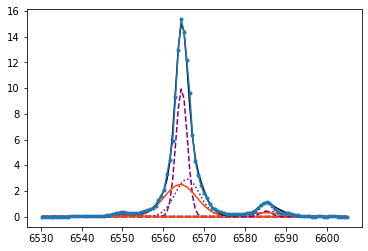

In [21]:
# Search for good initial guess
%matplotlib inline
plt.errorbar(wl_ha, flux_ha, noise_ha,
             marker='o', markersize=3, label='data')

# air
ha_wav = 6562.801
niib_wav = 6548.05
niia_wav = 6583.45

# narrow and broad

ha_nar = gaussian(wl_ha, 35, ha_wav, z=2.58e-04, sigma=1.4)
ha_mid = gaussian(wl_ha, 22, ha_wav, z=4.6966e-04, sigma=3.)
ha_brd = gaussian(wl_ha, 25, ha_wav, z=2.09e-04, sigma=4.)

niib_nar = gaussian(wl_ha, 0.6, niib_wav, z=2.58e-04, sigma=1.4)
niib_mid = gaussian(wl_ha, 0.8, niib_wav, z=4.6966e-04, sigma=3.)
niib_brd = gaussian(wl_ha, 0.8, niib_wav, z=2.09e-04, sigma=4.)

niia_nar = gaussian(wl_ha, 1.5, niia_wav, z=2.58e-04, sigma=1.4)
niia_mid = gaussian(wl_ha, 3, niia_wav, z=4.6966e-04, sigma=3.)
niia_brd = gaussian(wl_ha, 3, niia_wav, z=2.09e-04, sigma=4.)

# total
ha = ha_nar + ha_mid + ha_brd
niib = niib_nar + niib_mid + niib_brd
niia = niia_nar + niia_mid + niia_brd

plt.plot(wl_ha, ha_nar, color='purple', ls='--')
plt.plot(wl_ha, ha_mid, color='purple', ls=':')
plt.plot(wl_ha, ha_brd, color='orangered')

plt.plot(wl_ha, niib_nar, color='purple', ls='--')
plt.plot(wl_ha, niib_mid, color='purple', ls=':')
plt.plot(wl_ha, niib_brd, color='orangered')

plt.plot(wl_ha, niia_nar, color='purple', ls='--')
plt.plot(wl_ha, niia_mid, color='purple', ls=':')
plt.plot(wl_ha, niia_brd, color='orangered')

plt.plot(wl_ha, niib + ha + niia, color='black')

In [22]:
params_ha_nii = Parameters()

params_ha_nii.add('z_nar', value=2.58e-04)
params_ha_nii.add('z_mid', value=4.6966e-04)
params_ha_nii.add('z_brd', value=2.09e-04)

params_ha_nii.add('sigma_nar', value=1.4, min=0.)
params_ha_nii.add('sigma_mid', value=3., min=0.)
params_ha_nii.add('sigma_brd', value=4., min=0.)

params_ha_nii.add('Ha_nar', value=35, min=0.)
params_ha_nii.add('Ha_mid', value=22, min=0.)
params_ha_nii.add('Ha_brd', value=25, min=0.)

params_ha_nii.add('Niia_to_ha', value=1/30, min=0.)
params_ha_nii.add('Niib_to_niia', value=1/3, min=0.)


def residual_ha_nii(params_ha_nii, x, data, uncertainty):
    ha_wav = 6562.801
    niib_wav = 6548.05
    niia_wav = 6583.45
    
    z_nar = params_ha_nii['z_nar']
    z_mid = params_ha_nii['z_mid']
    z_brd = params_ha_nii['z_brd']
    
    sigma_nar = params_ha_nii['sigma_nar']
    sigma_mid = params_ha_nii['sigma_mid']
    sigma_brd = params_ha_nii['sigma_brd']
    
    ha_nar = params_ha_nii['Ha_nar']
    ha_mid = params_ha_nii['Ha_mid']
    ha_brd = params_ha_nii['Ha_brd']
    
    niia_nar = params_ha_nii['Ha_nar']*params_ha_nii['Niia_to_ha']
    niia_mid = params_ha_nii['Ha_mid']*params_ha_nii['Niia_to_ha']
    niia_brd = params_ha_nii['Ha_brd']*params_ha_nii['Niia_to_ha']
    
    niib_nar = niia_nar*params_ha_nii['Niib_to_niia']
    niib_mid = niia_mid*params_ha_nii['Niib_to_niia']
    niib_brd = niia_brd*params_ha_nii['Niib_to_niia']
    
    x = wl_ha
    
    model_ha = gaussian(x, ha_nar, ha_wav, z_nar, sigma_nar) \
             + gaussian(x, ha_brd, ha_wav, z_brd, sigma_brd) \
             + gaussian(x, ha_mid, ha_wav, z_mid, sigma_mid)
    
    model_niia = gaussian(x, niia_nar, niia_wav, z_nar, sigma_nar) \
               + gaussian(x, niia_brd, niia_wav, z_brd, sigma_brd) \
               + gaussian(x, niia_mid, niia_wav, z_mid, sigma_mid)
    
    model_niib = gaussian(x, niib_nar, niib_wav, z_nar, sigma_nar) \
               + gaussian(x, niib_brd, niib_wav, z_brd, sigma_brd) \
               + gaussian(x, niib_mid, niib_wav, z_mid, sigma_mid)
    
    model = model_niib + model_ha + model_niia
    return (model - flux_ha) / noise_ha

In [23]:
out_ha_nii = minimize(residual_ha_nii, params_ha_nii, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=3000, thin=10,
                      workers=12, nwalkers=36, seed=1)

100%|██████████████████████████████████████| 3000/3000 [00:23<00:00, 128.07it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 11 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 60;
tau: [121.13367057 202.59188542 394.10014112 317.30170745 223.31433239
 416.98630247 287.11497436 402.65723583 380.2345609  394.08190482
 173.80237505]


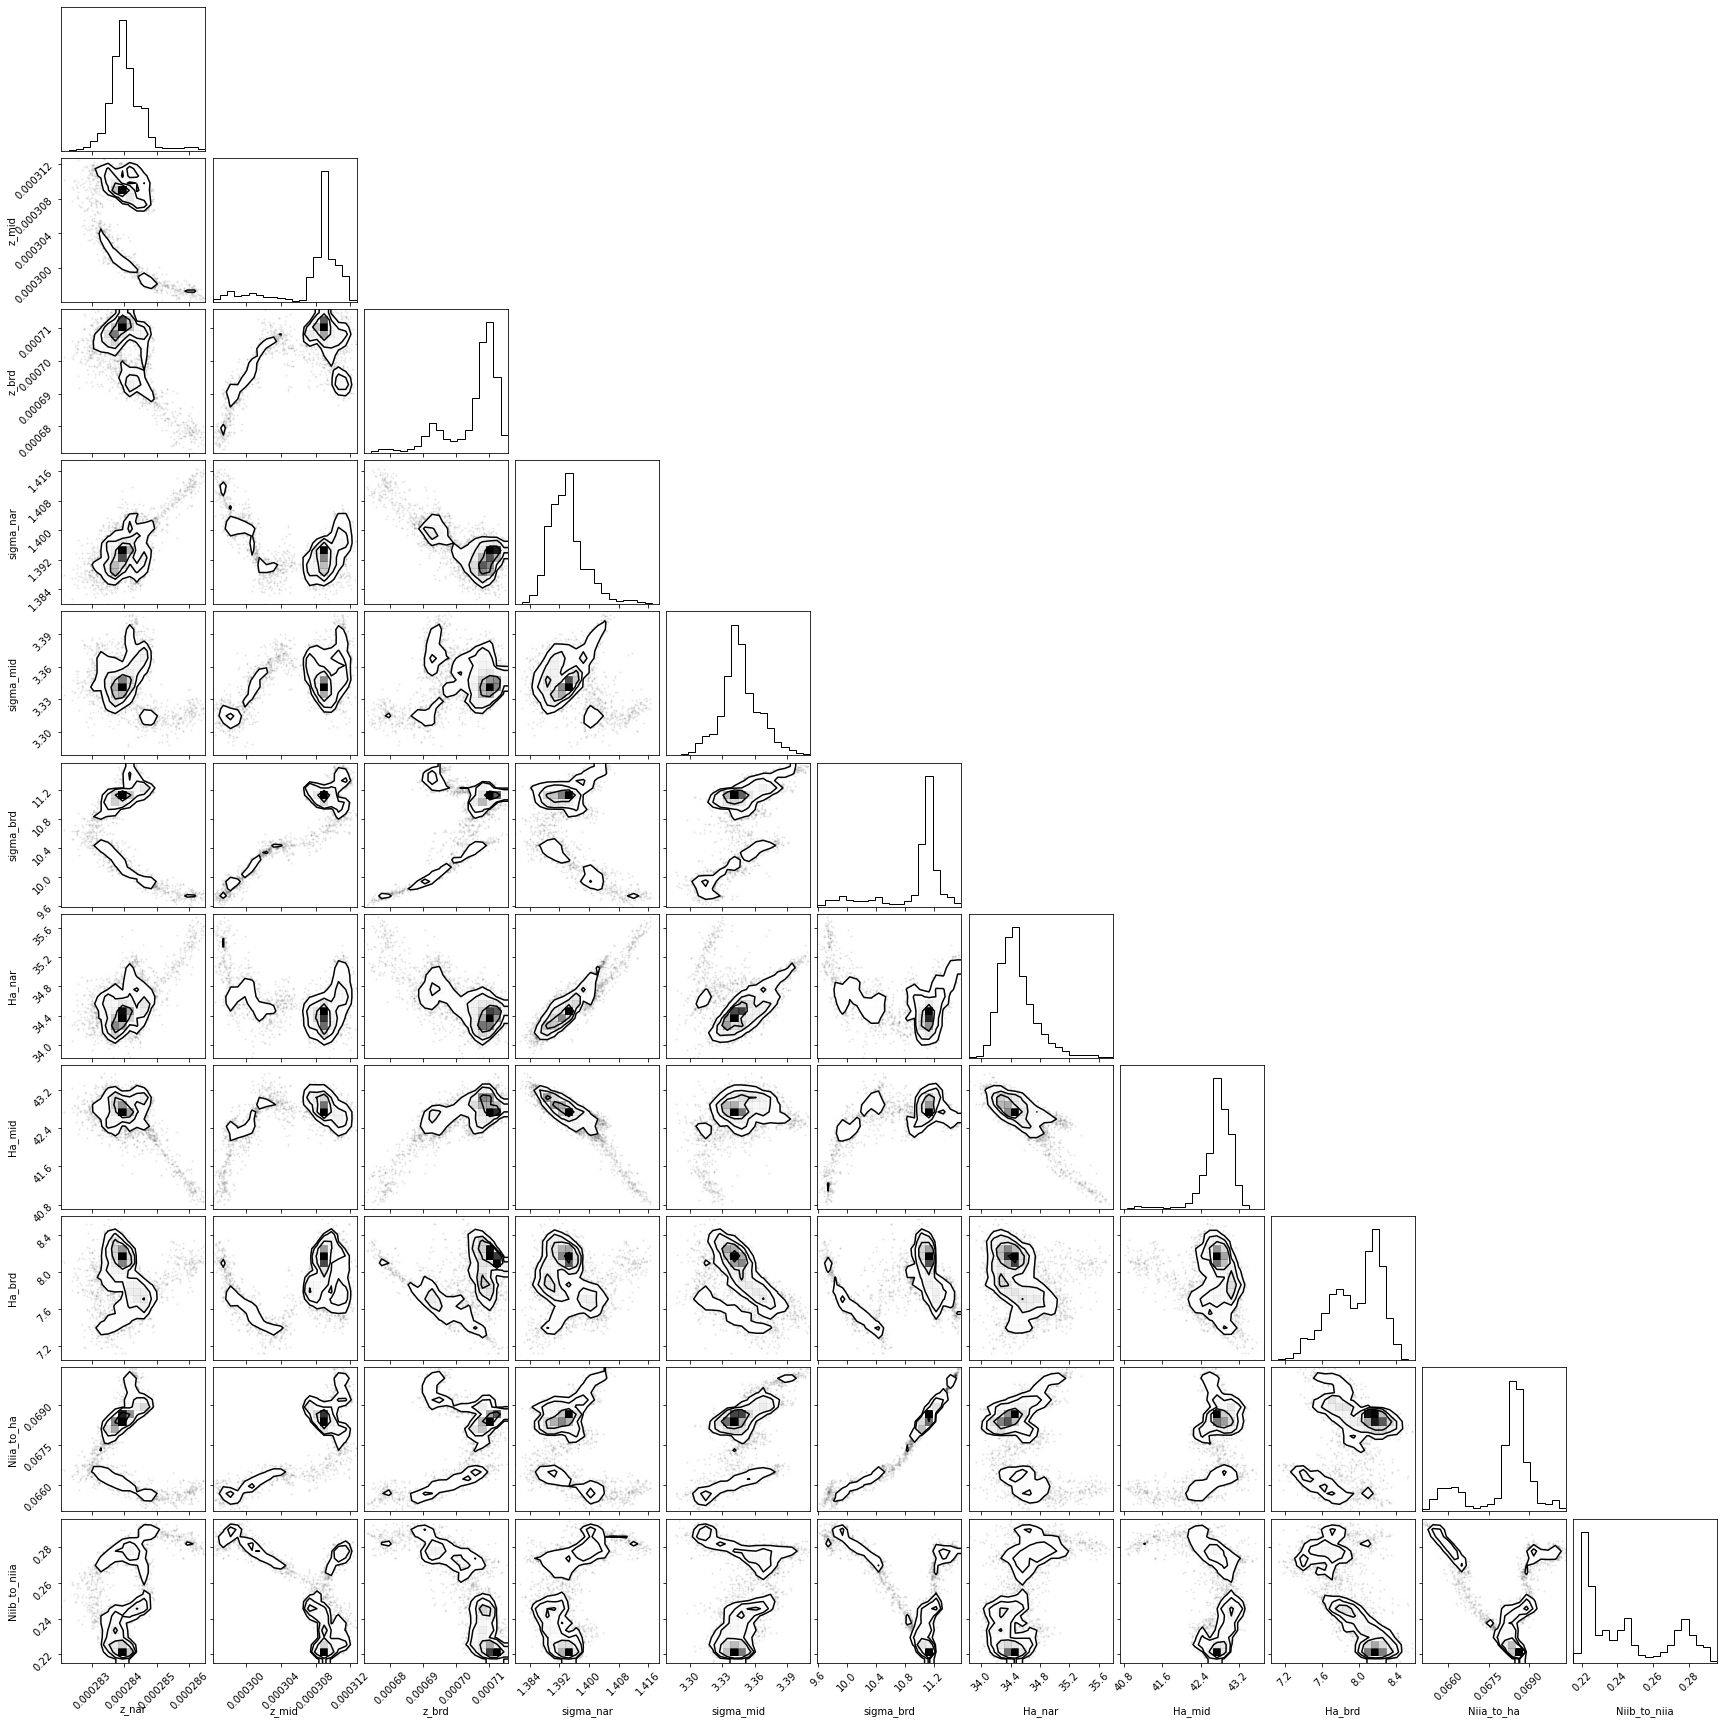

In [24]:
%matplotlib inline
corner.corner(out_ha_nii.flatchain, labels=out_ha_nii.var_names);

In [25]:
out_ha_nii

(6530.0, 6600.0)

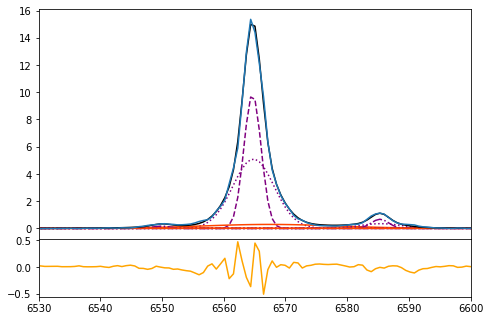

In [27]:
ha_nar = out_ha_nii.flatchain.Ha_nar.mean()
ha_mid = out_ha_nii.flatchain.Ha_mid.mean()
ha_brd = out_ha_nii.flatchain.Ha_brd.mean()

niia_nar = (out_ha_nii.flatchain.Ha_nar*out_ha_nii.flatchain.Niia_to_ha).mean()
niia_mid = (out_ha_nii.flatchain.Ha_mid*out_ha_nii.flatchain.Niia_to_ha).mean()
niia_brd = (out_ha_nii.flatchain.Ha_brd*out_ha_nii.flatchain.Niia_to_ha).mean()

niib_nar = (out_ha_nii.flatchain.Ha_nar*out_ha_nii.flatchain.Niia_to_ha*out_ha_nii.flatchain.Niib_to_niia).mean()
niib_mid = (out_ha_nii.flatchain.Ha_nar*out_ha_nii.flatchain.Niia_to_ha*out_ha_nii.flatchain.Niib_to_niia).mean()
niib_brd = (out_ha_nii.flatchain.Ha_nar*out_ha_nii.flatchain.Niia_to_ha*out_ha_nii.flatchain.Niib_to_niia).mean()

z_ha_nar = out_ha_nii.flatchain.z_nar.mean()
z_ha_mid = out_ha_nii.flatchain.z_mid.mean()
z_ha_brd = out_ha_nii.flatchain.z_brd.mean()

sigma_ha_nar = out_ha_nii.flatchain.sigma_nar.mean()
sigma_ha_mid = out_ha_nii.flatchain.sigma_mid.mean()
sigma_ha_brd = out_ha_nii.flatchain.sigma_brd.mean()

# Search for good initial guess
%matplotlib inline
fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))
ax.errorbar(wl_ha, flux_ha, noise_ha, markersize=2, label='data')

ha_wav = 6562.801
niib_wav = 6548.05
niia_wav = 6583.45

niib_nar = gaussian(wl_ha, niib_nar, niib_wav, z=z_ha_nar, sigma=sigma_ha_nar)
niib_mid = gaussian(wl_ha, niib_mid, niib_wav, z=z_ha_mid, sigma=sigma_ha_mid)
niib_brd = gaussian(wl_ha, niib_brd, niib_wav, z=z_ha_brd, sigma=sigma_ha_brd)

ha_nar = gaussian(wl_ha, ha_nar, ha_wav, z=z_ha_nar, sigma=sigma_ha_nar)
ha_mid = gaussian(wl_ha, ha_mid, ha_wav, z=z_ha_mid, sigma=sigma_ha_mid)
ha_brd = gaussian(wl_ha, ha_brd, ha_wav, z=z_ha_brd, sigma=sigma_ha_brd)

niia_nar = gaussian(wl_ha, niia_nar, niia_wav, z=z_ha_nar, sigma=sigma_ha_nar)
niia_mid = gaussian(wl_ha, niia_mid, niia_wav, z=z_ha_mid, sigma=sigma_ha_mid)
niia_brd = gaussian(wl_ha, niia_brd, niia_wav, z=z_ha_brd, sigma=sigma_ha_brd)

ha = ha_nar + ha_mid + ha_brd
niia = niia_nar + niia_mid + niia_brd
niib = niib_nar + niib_mid+ niib_brd

ax.plot(wl_ha, ha_nar, color='purple', ls='--')
ax.plot(wl_ha, ha_mid, color='purple', ls=':')
ax.plot(wl_ha, ha_brd, color='orangered')

ax.plot(wl_ha, niia_nar, color='purple', ls='-.')
ax.plot(wl_ha, niia_mid, color='purple', ls=':')
ax.plot(wl_ha, niia_brd, color='orangered')

ax.plot(wl_ha, niib_nar, color='purple', ls='-.')
ax.plot(wl_ha, niib_mid, color='purple', ls=':')
ax.plot(wl_ha, niib_brd, color='orangered')
ax.set_xticks([])
ax.plot(wl_ha, niib + ha + niia, color='black')
ax1.plot(wl_ha, niib + ha + niia - flux_ha, color='orange')

ax.set_xlim(6530, 6600)
ax1.set_xlim(6530, 6600)